## Comparación de Modelos

Una vez ajustados los dos modelos, comparamos sus desempeños a través de métricas y gráficos con el objetivo de determinar cuál de estos es el mejor para estimar la probabilidad de que un bateador haga *swing* ante un determinado pitcheo. Una vez elegido, lo usaremos para generar predicciones para los pitcheos incluidos en *temporada2.parquet*.

In [1]:
import polars as pl
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score, roc_curve
import pyprojroot
import matplotlib.pyplot as plt

ROOT = pyprojroot.here()

Cargamos los datos junto con las probabilidades estimadas por ambos modelos, para los datos del conjunto de validación. Luego, calculamos las métricas que utilizaremos para su comparación, basadas en las probabilidades predichas. 

La métrica principal es el *Log-Loss*:  $$\text{LogLoss} = -\frac{1}{n}\sum_{i=1}^{n} \left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) \right]$$ donde $y_i$ indica si hubo swing y $\hat{p}_i$ es la probabilidad predicha de swing.

Esta métrica considera la incertidumbre y el nivel de confianza del modelo, favoreciendo aquellos que distinguen y calibran mejor la separación entre clases.  

Además se considera el *Brier Score*: $$\text{Brier Score} = \frac{1}{n} \sum_{i=1}^{n} (y_i-\hat{p}_i)^2$$

Este mide la precisión de los pronósticos mediante el promedio de las diferencias al cuadrado entre las probabilidades predichas y el resultado real. De esta manera, evalúa tanto la discriminación entre clases como su calibración.

También calculamos y graficamos el área bajo la curva roc (AUC-ROC) de cada uno de los modelos, que que mide la capacidad del modelo para discriminar entre las clases, independientemente del punto de corte utilizado


In [5]:
datos_con_predicciones = pl.read_parquet(
    ROOT / "Datos" / "datos_con_predicciones.parquet"
)

swing_real = datos_con_predicciones["Swing"].to_numpy()
prob_xgboost = datos_con_predicciones["probabilidades_xgb"].to_numpy()
prob_regresion = datos_con_predicciones["probabilidades_regresion"].to_numpy()

# Calculamos las métricas para el Modelo XGBoost
logloss_1 = log_loss(swing_real, prob_xgboost)
brier_1 = brier_score_loss(swing_real, prob_xgboost)
auc_1 = roc_auc_score(swing_real, prob_xgboost)

# Calculamos las métricas para el Modelo 2
logloss_2 = log_loss(swing_real, prob_regresion)
brier_2 = brier_score_loss(swing_real, prob_regresion)
auc_2 = roc_auc_score(swing_real, prob_regresion)

# Armamos la tabla comparativa directamente en Polars
tabla_comparativa = pl.DataFrame(
    {
        "Métrica": ["Log-Loss", "Brier Score", "AUC-ROC"],
        "XGBoost": [round(logloss_1, 4), round(brier_1, 4), round(auc_1, 4)],
        "Regresión": [round(logloss_2, 4), round(brier_2, 4), round(auc_2, 4)],
    }
)

tabla_comparativa

Métrica,XGBoost,Regresión
str,f64,f64
"""Log-Loss""",0.0781,0.572
"""Brier Score""",0.0172,0.1923
"""AUC-ROC""",0.996,0.7699


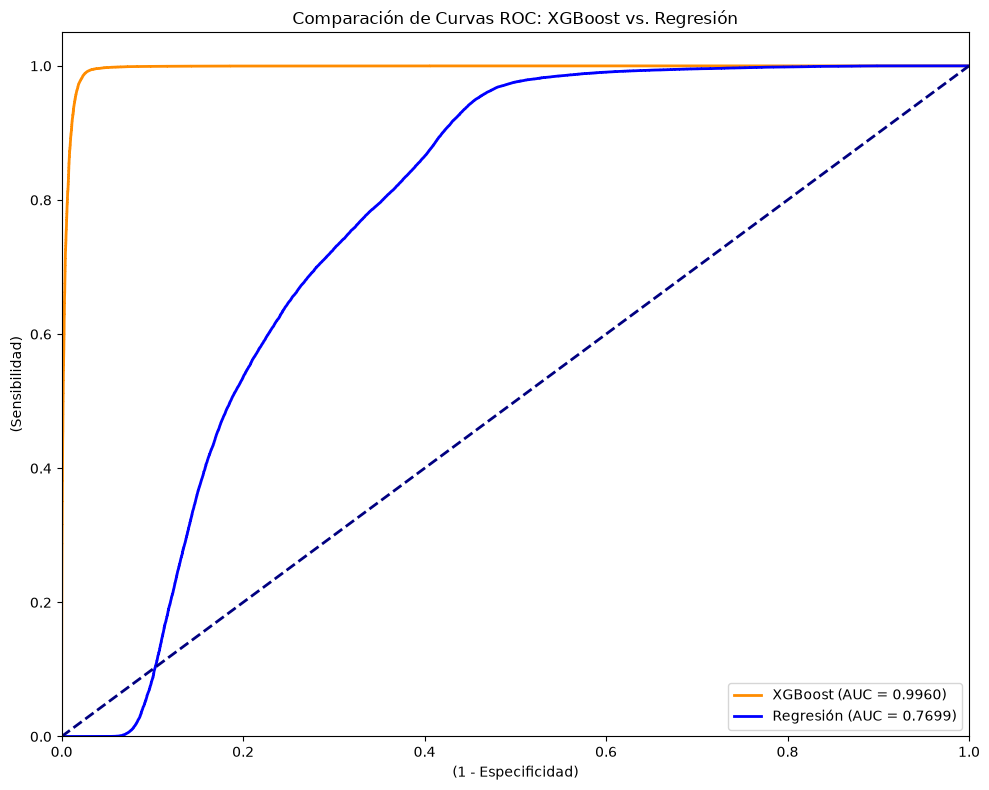

In [6]:
# Modelo XGBoost
fpr1, tpr1, _ = roc_curve(swing_real, prob_xgboost)
auc1 = roc_auc_score(swing_real, prob_xgboost)

# Regresión
fpr2, tpr2, _ = roc_curve(swing_real, prob_regresion)
auc2 = roc_auc_score(swing_real, prob_regresion)

plt.figure(figsize=(10, 8))

# Graficamos la curva del Modelo XGBoost
plt.plot(fpr1, tpr1, color="darkorange", lw=2, label=f"XGBoost (AUC = {auc1:.4f})")

# Graficamos la curva de la Regresión
plt.plot(fpr2, tpr2, color="blue", lw=2, label=f"Regresión (AUC = {auc2:.4f})")

plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("(1 - Especificidad)")
plt.ylabel("(Sensibilidad)")
plt.title("Comparación de Curvas ROC: XGBoost vs. Regresión")
plt.legend(loc="lower right")

# Mostramos el gráfico
plt.tight_layout()
plt.show()

Analizando las métricas calculadas, observamos que el modelo XGBoost presenta un rendimiento superior que el modelo de regresión logística. Este resultado era esperable ya que XGBoost se basa en un conjunto de árboles de decisión capaces de capturar relaciones no lineales e interacciones entre predictores.

De esta manera, el modelo XGBoost es el elegido para predecir los valores de la temporada 2. 